In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [128]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

x = mnist.data
y = mnist.target

print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


In [129]:
y = mnist.target.astype('int64')

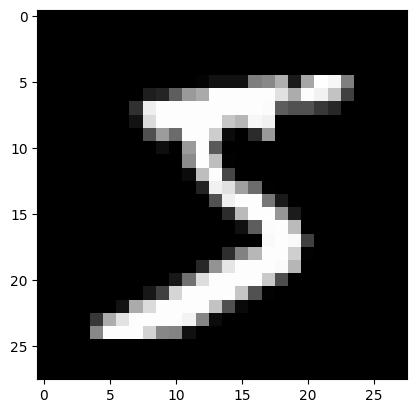

In [130]:
plt.imshow(x[0].reshape(28,28),cmap='gray')

In [131]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [132]:
from sklearn.preprocessing import MinMaxScaler

In [133]:
mx=MinMaxScaler()

In [134]:
x_train=mx.fit_transform(x_train)
x_test=mx.transform(x_test)

In [135]:
x_train.shape

(56000, 784)

In [136]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [137]:
model=Sequential()
model.add(Dense(25,activation='relu',input_dim=784))
model.add(Dense(15,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,285 (79.24 KB)

 Trainable params: 20,285 (79.24 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [140]:
history = model.fit(x_train,y_train,batch_size=50,epochs=15,verbose=1,validation_split=0.2)

Epoch 1/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7868 - loss: 0.6649 - val_accuracy: 0.9185 - val_loss: 0.2831
Epoch 2/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9282 - loss: 0.2488 - val_accuracy: 0.9301 - val_loss: 0.2426
Epoch 3/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9419 - loss: 0.2001 - val_accuracy: 0.9378 - val_loss: 0.2109
Epoch 4/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9492 - loss: 0.1729 - val_accuracy: 0.9456 - val_loss: 0.1860
Epoch 5/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9550 - loss: 0.1539 - val_accuracy: 0.9484 - val_loss: 0.1760
Epoch 6/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9584 - loss: 0.1390 - val_accuracy: 0.9431 - val_loss: 0.1902
Epoch 7/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9625 - loss: 0.1267 - val_accuracy: 0.9540 - val_loss: 0.1624
Epoch 8/15
896/896 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9642 - loss: 0.1201 - val_accuracy: 0.

In [141]:
y_pred=model.predict(x_test)

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [142]:
y_pred

array([[7.69161818e-12, 1.11128656e-13, 1.07557263e-09, ...,
        3.37375324e-14, 9.99941826e-01, 1.45820689e-08],
       [3.28511632e-14, 5.78085952e-08, 1.16594069e-11, ...,
        1.73037333e-05, 3.09319431e-10, 6.09949420e-05],
       [1.50026553e-05, 8.87695351e-04, 1.98848167e-04, ...,
        5.67417010e-05, 9.34342802e-01, 1.20167679e-03],
       ...,
       [1.01911958e-10, 2.12090861e-04, 9.99413013e-01, ...,
        4.99268162e-06, 3.12866410e-04, 5.14759730e-13],
       [1.53133719e-08, 2.55470489e-11, 8.11061000e-07, ...,
        9.99990225e-01, 2.21713412e-10, 3.89713796e-06],
       [1.02886781e-13, 9.99527395e-01, 2.34141498e-05, ...,
        3.57184384e-04, 2.77548643e-05, 2.88649069e-08]], dtype=float32)

In [143]:
y_pred_final = y_pred.argmax(axis=1)

In [144]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_final)

0.9512142857142857

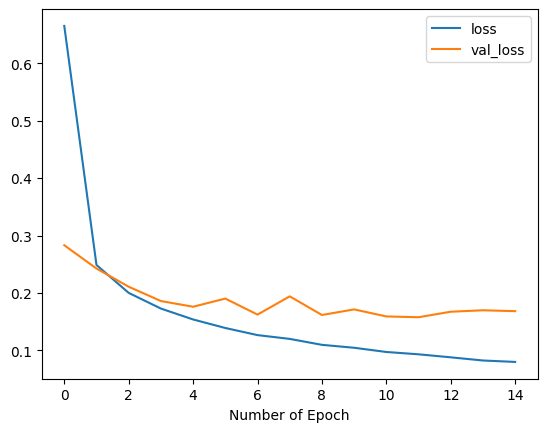

In [145]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('Number of Epoch')
plt.legend()

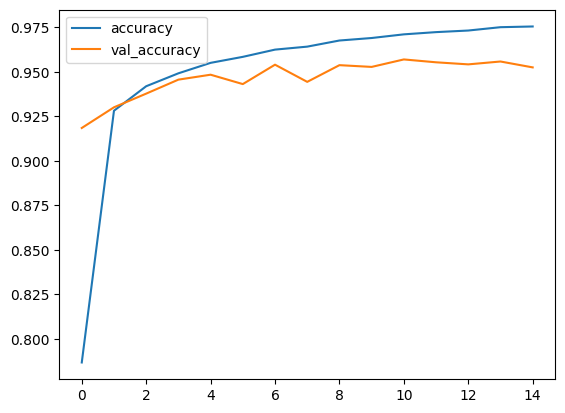

In [146]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()